# ML - Pipeline 

## Import and Dataset

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay



In [47]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})


In [48]:
students 

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0
...,...,...,...,...,...,...
595,596,A,11.6,6.0,100.0,100.0
596,597,A,10.0,9.1,72.0,80.7
597,598,B,14.9,6.6,90.1,96.7
598,599,C,7.5,7.0,95.6,86.9


In [49]:
print(students.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    object 
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 28.2+ KB
None


In [50]:
print(students.isnull().sum())

student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64


In [51]:
print(students.describe())

       student_id  study_hours_per_week  sleep_hours_per_night  \
count  600.000000            600.000000             600.000000   
mean   300.500000             10.089333               7.046000   
std    173.349358              3.407213               1.122787   
min      1.000000              0.400000               3.400000   
25%    150.750000              7.700000               6.275000   
50%    300.500000             10.000000               7.100000   
75%    450.250000             12.500000               7.800000   
max    600.000000             21.900000              10.000000   

       attendance_pct  exam_score  
count      600.000000  600.000000  
mean        85.583000   88.605000  
std          9.137597   10.205279  
min         62.000000   58.900000  
25%         78.900000   81.750000  
50%         85.700000   90.200000  
75%         92.325000   98.700000  
max        100.000000  100.000000  


## Feature engineering (one-hot encode class_section)

In [52]:
X = pd.get_dummies(students[["study_hours_per_week", "sleep_hours_per_night",
                              "attendance_pct", "class_section"]],
                    columns=["class_section"], drop_first=True)
y = students["exam_score"]

print(X.columns.tolist())
print(X.shape)

['study_hours_per_week', 'sleep_hours_per_night', 'attendance_pct', 'class_section_B', 'class_section_C']
(600, 5)


## Split once with a fixed seed

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(480, 5) (120, 5)


## Regression Baseline 


In [54]:
baseline_reg = DummyRegressor(strategy="mean")
baseline_reg.fit(X_train, y_train)

baseline_preds = baseline_reg.predict(X_test)
baseline_rmse = mean_squared_error(y_test, baseline_preds) ** 0.5
baseline_r2 = r2_score(y_test, baseline_preds)

print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline RMSE: 10.30
Baseline R²: -0.0096


## Real Linear Regression

In [55]:
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

print(f"Model RMSE: {rmse:.2f}")
print(f"Model R²: {r2:.4f}")
print(f"Improvement over baseline: RMSE dropped by {baseline_rmse - rmse:.2f}, "
      f"R² improved from {baseline_r2:.4f} to {r2:.4f}")

Model RMSE: 7.06
Model R²: 0.5257
Improvement over baseline: RMSE dropped by 3.24, R² improved from -0.0096 to 0.5257


In [56]:
improvement_rmse = baseline_rmse - rmse
r2_pct = r2 * 100

summary = (
    f"The linear regression model reduced RMSE from {baseline_rmse:.2f} to {rmse:.2f} "
    f"and improved R² from roughly {baseline_r2:.2f} to {r2:.2f}, meaning it explains "
    f"about {r2_pct:.0f}% of the variance in exam scores."
)
print(summary)

The linear regression model reduced RMSE from 10.30 to 7.06 and improved R² from roughly -0.01 to 0.53, meaning it explains about 53% of the variance in exam scores.


## Coefficients 

In [57]:
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.4f}")

study_hours_per_week: 2.0330
sleep_hours_per_night: -0.0107
attendance_pct: 0.0887
class_section_B: 0.1248
class_section_C: 3.1304


The largest effect comes from class_section_C (+3.13) and study_hours_per_week (+2.03),study hours matters most per hour studied, but Section C gives the single biggest jump for any one feature. Both match Monday: study hours had a strong correlation with exam score (r = 0.69), and Section C's edge over Section A (91.36 vs 87.61) was confirmed by a bootstrap CI that excluded zero. Sleep hours barely mattered in either near-zero correlation on Monday (r = -0.02) and a near-zero coefficient today (-0.0107).

## Classification target and class balance check

In [58]:
students["distinction"] = (students["exam_score"] >= 85).astype(int)
distinction_rate = students["distinction"].mean()
print(f"Fraction with distinction: {distinction_rate:.4f}")

Fraction with distinction: 0.6533


In [59]:
print(f"About {distinction_rate * 100:.4f}% of students hit the threshhold")

About 65.3333% of students hit the threshhold


In [60]:
print(students["distinction"].value_counts())

distinction
1    392
0    208
Name: count, dtype: int64


## Classification Baseline

In [61]:
y_clf = students["distinction"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

baseline_clf = DummyClassifier(strategy="most_frequent")
baseline_clf.fit(Xc_train, yc_train)
base_preds = baseline_clf.predict(Xc_test)

base_acc = accuracy_score(yc_test, base_preds)
base_prec = precision_score(yc_test, base_preds, zero_division=0)
base_rec = recall_score(yc_test, base_preds, zero_division=0)
base_f1 = f1_score(yc_test, base_preds, zero_division=0)

print(f"Accuracy: {base_acc:.4f}, Precision: {base_prec:.4f}, Recall: {base_rec:.4f}, F1: {base_f1:.4f}")

Accuracy: 0.6500, Precision: 0.6500, Recall: 1.0000, F1: 0.7879


In [62]:
summary_baseline = (
    f"The baseline achieved {base_acc * 100:.2f}% accuracy by always predicting "
    f"the majority class, so accuracy alone is misleading because it had {base_prec * 100:.2f}% "
    f"precision and learned no useful pattern from the features."
)
print(summary_baseline)

The baseline achieved 65.00% accuracy by always predicting the majority class, so accuracy alone is misleading because it had 65.00% precision and learned no useful pattern from the features.


## Logistic Regression Model

In [63]:
clf_lr = LogisticRegression(random_state=42, max_iter=1000)
clf_lr.fit(Xc_train, yc_train)
clf_lr_preds = clf_lr.predict(Xc_test)

acc = accuracy_score(yc_test, clf_lr_preds)
prec = precision_score(yc_test, clf_lr_preds, zero_division=0)
rec = recall_score(yc_test, clf_lr_preds, zero_division=0)
f1 = f1_score(yc_test, clf_lr_preds, zero_division=0)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

Accuracy: 0.7667, Precision: 0.8125, Recall: 0.8333, F1: 0.8228


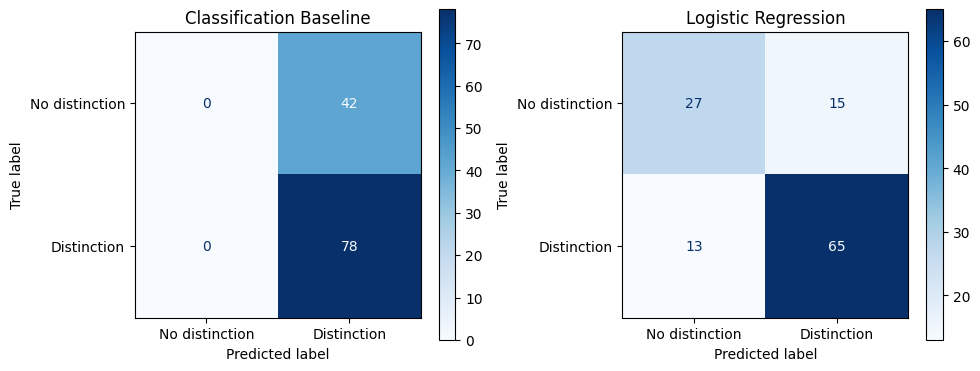

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    yc_test,
    base_preds,
    display_labels=["No distinction", "Distinction"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Classification Baseline")

ConfusionMatrixDisplay.from_predictions(
    yc_test,
    clf_lr_preds,
    display_labels=["No distinction", "Distinction"],
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

In [65]:
summary_logistic = (
    f"Logistic regression achieved {acc * 100:.2f}% accuracy, "
    f"{prec * 100:.2f}% precision, {rec * 100:.2f}% recall, "
    f"and {f1 * 100:.2f}% F1 score. Compared with the baseline, "
    f"accuracy increased by {(acc - base_acc) * 100:.2f} percentage points, "
    f"precision increased by {(prec - base_prec) * 100:.2f} percentage points, "
    f"recall decreased by {(base_rec - rec) * 100:.2f} percentage points, "
    f"and F1 score increased by {(f1 - base_f1) * 100:.2f} percentage points."
)

print(summary_logistic)

Logistic regression achieved 76.67% accuracy, 81.25% precision, 83.33% recall, and 82.28% F1 score. Compared with the baseline, accuracy increased by 11.67 percentage points, precision increased by 16.25 percentage points, recall decreased by 16.67 percentage points, and F1 score increased by 3.49 percentage points.
